In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hourly-energy-consumption/est_hourly.paruqet
/kaggle/input/hourly-energy-consumption/DOM_hourly.csv
/kaggle/input/hourly-energy-consumption/EKPC_hourly.csv
/kaggle/input/hourly-energy-consumption/DUQ_hourly.csv
/kaggle/input/hourly-energy-consumption/DAYTON_hourly.csv
/kaggle/input/hourly-energy-consumption/PJME_hourly.csv
/kaggle/input/hourly-energy-consumption/PJM_Load_hourly.csv
/kaggle/input/hourly-energy-consumption/NI_hourly.csv
/kaggle/input/hourly-energy-consumption/FE_hourly.csv
/kaggle/input/hourly-energy-consumption/COMED_hourly.csv
/kaggle/input/hourly-energy-consumption/AEP_hourly.csv
/kaggle/input/hourly-energy-consumption/pjm_hourly_est.csv
/kaggle/input/hourly-energy-consumption/DEOK_hourly.csv
/kaggle/input/hourly-energy-consumption/PJMW_hourly.csv


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import seaborn as sns
from sklearn.metrics import mean_squared_error
color_pal=sns.color_palette()
plt.style.use('fivethirtyeight')

In [3]:
df =pd.read_csv("/kaggle/input/hourly-energy-consumption/PJME_hourly.csv")
df=df.set_index('Datetime')
df.index= pd.to_datetime(df.index)
df = df.sort_index()

<Axes: title={'center': 'PJME Energy Consumption in MW'}, xlabel='Datetime'>

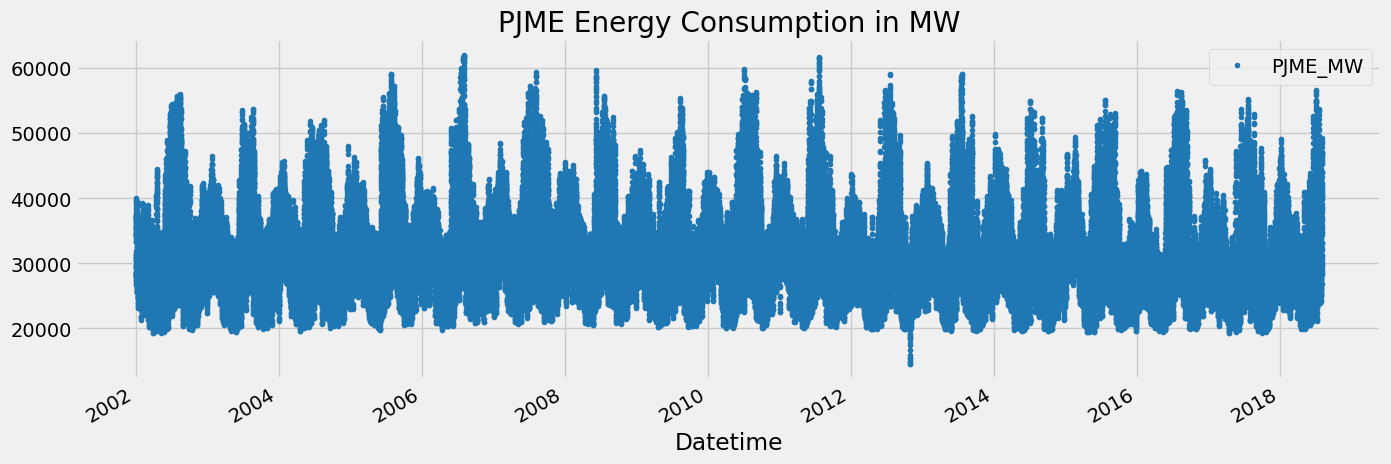

In [4]:
df.plot(style='.',figsize=(15,5),color=color_pal[0],title='PJME Energy Consumption in MW')

In [5]:
df.index

DatetimeIndex(['2002-01-01 01:00:00', '2002-01-01 02:00:00',
               '2002-01-01 03:00:00', '2002-01-01 04:00:00',
               '2002-01-01 05:00:00', '2002-01-01 06:00:00',
               '2002-01-01 07:00:00', '2002-01-01 08:00:00',
               '2002-01-01 09:00:00', '2002-01-01 10:00:00',
               ...
               '2018-08-02 15:00:00', '2018-08-02 16:00:00',
               '2018-08-02 17:00:00', '2018-08-02 18:00:00',
               '2018-08-02 19:00:00', '2018-08-02 20:00:00',
               '2018-08-02 21:00:00', '2018-08-02 22:00:00',
               '2018-08-02 23:00:00', '2018-08-03 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=145366, freq=None)

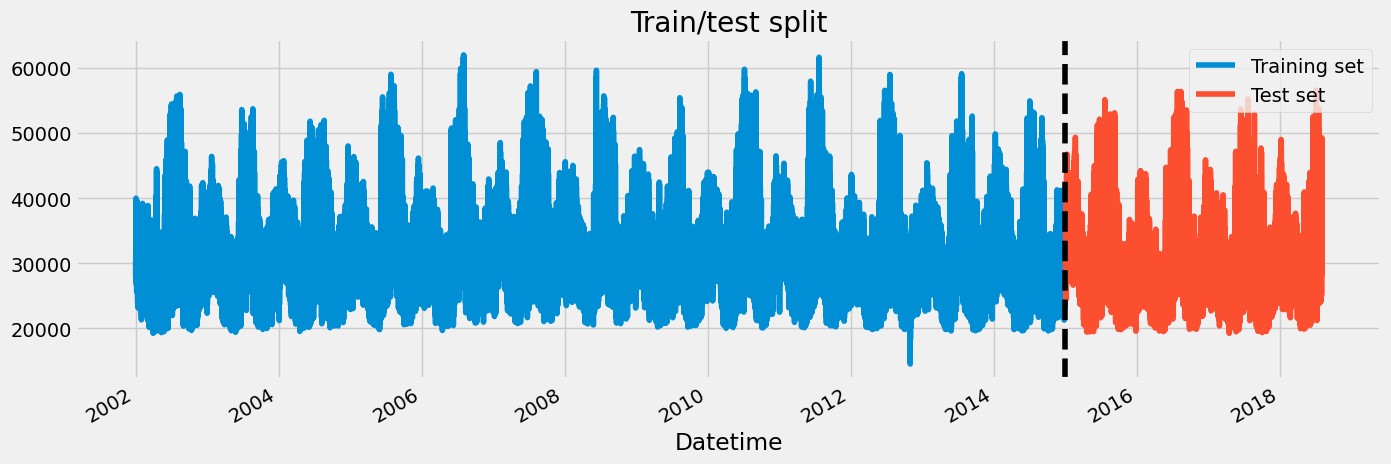

In [6]:
train=df.loc[df.index<'01-01-2015']
test=df.loc[df.index>='01-01-2015']
fig,ax=plt.subplots(figsize=(15,5))
train.plot(ax=ax,label='Training set',title="Train/test split")
test.plot(ax=ax,label='Test set')
ax.axvline('01-01-2015',color='black',ls='--')
ax.legend(["Training set","Test set"])
plt.show()

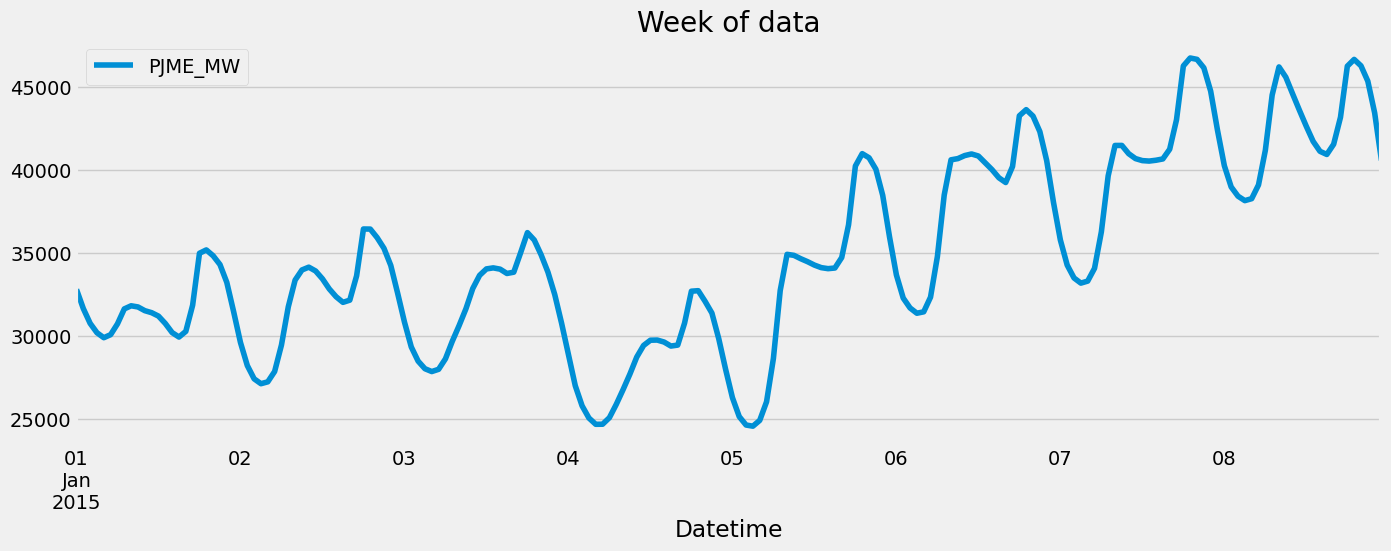

In [7]:
df.loc['2015-01-01':'2015-01-08'].plot(
    figsize=(15,5),
    title='Week of data'
)
plt.show()


In [8]:
def create_features(df):
    """
    Create time series features based on time series index
    """
    df=df.copy()
    df['hour']=df.index.hour
    df['dayofweek']=df.index.dayofweek
    df['quarter']=df.index.quarter
    df['month']=df.index.month
    df['year']=df.index.year
    df['dayofyear']=df.index.dayofyear
    return df

In [9]:
df=create_features(df)

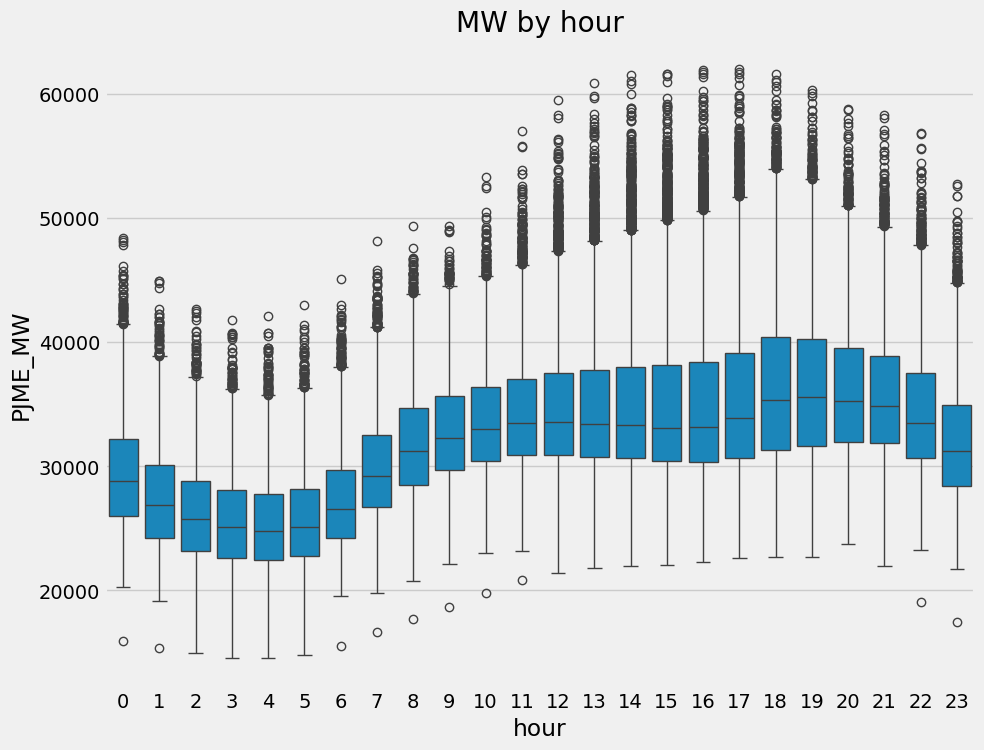

In [10]:
fig,ax=plt.subplots(figsize=(10,8))
sns.boxplot(data=df,x='hour',y='PJME_MW')
ax.set_title("MW by hour")
plt.show()

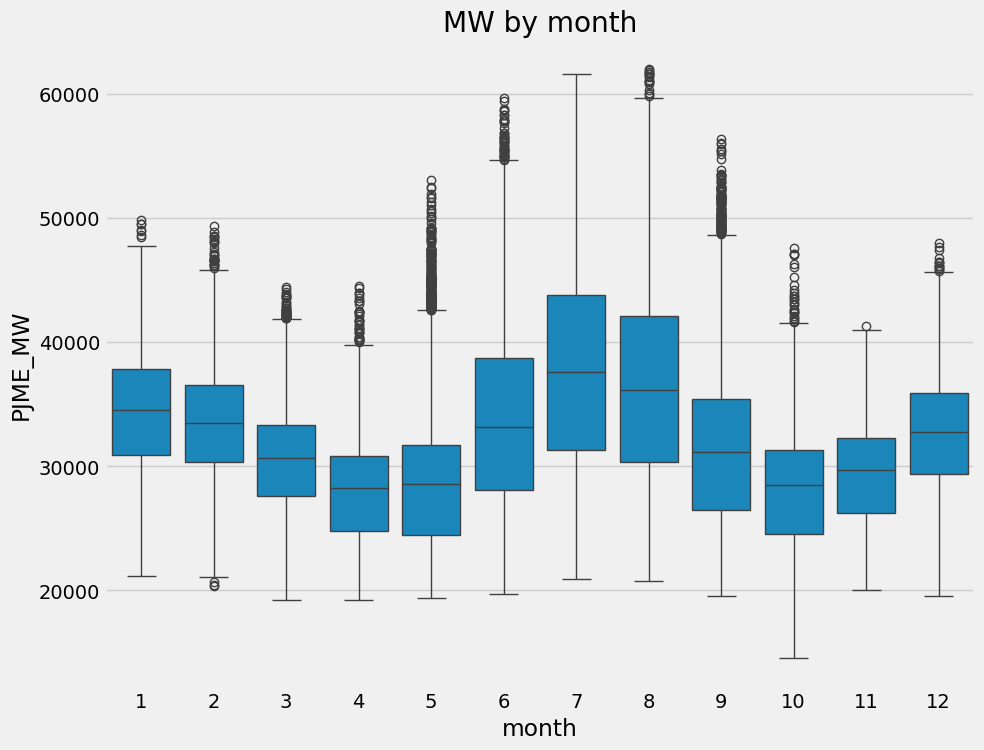

In [11]:
fig,ax=plt.subplots(figsize=(10,8))
sns.boxplot(data=df,x='month',y='PJME_MW')
ax.set_title("MW by month")
plt.show()

In [12]:
train=create_features(train)
test=create_features(test)

In [13]:
df.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear'],
      dtype='object')

In [14]:
FEATURES=['hour', 'dayofweek', 'quarter', 'month', 'year','dayofyear']
TARGET='PJME_MW'
X_train=train[FEATURES]
y_train=train[TARGET]
X_test=test[FEATURES]
y_test=test[TARGET]


In [15]:
reg=xgb.XGBRegressor(n_estimators=1000,early_stopping_rounds=50,learning_rate=0.001)
reg.fit(X_train,y_train,eval_set=[(X_train,y_train),(X_test,y_test)],verbose=100)
#verbose=True gave us the values at each round but if i put for example 100 it would give me the results for each 100 rounds

[0]	validation_0-rmse:6447.78573	validation_1-rmse:6517.54145
[100]	validation_0-rmse:6026.49339	validation_1-rmse:6131.08053
[200]	validation_0-rmse:5654.75124	validation_1-rmse:5796.65490
[300]	validation_0-rmse:5326.88030	validation_1-rmse:5505.59274
[400]	validation_0-rmse:5039.56899	validation_1-rmse:5253.21086
[500]	validation_0-rmse:4788.58887	validation_1-rmse:5034.74880
[600]	validation_0-rmse:4565.97498	validation_1-rmse:4847.76655
[700]	validation_0-rmse:4372.19812	validation_1-rmse:4687.11295
[800]	validation_0-rmse:4202.53312	validation_1-rmse:4547.57144
[900]	validation_0-rmse:4055.65261	validation_1-rmse:4427.00726
[999]	validation_0-rmse:3929.32983	validation_1-rmse:4325.35302


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.001, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
fi= pd.DataFrame(data=reg.feature_importances_,index=reg.feature_names_in_,columns=['importance'])

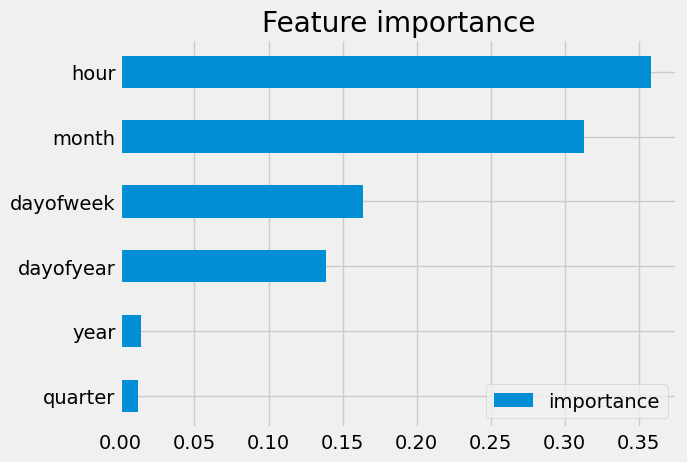

In [17]:
fi.sort_values('importance').plot(kind='barh',title='Feature importance')
plt.show()

In [18]:
test['prediction']=reg.predict(X_test)
test

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,prediction
Datetime,,,,,,,,
2015-01-01 00:00:00,32802.0,0,3,1,1,2015,1,32089.679688
2015-01-01 01:00:00,31647.0,1,3,1,1,2015,1,31160.828125
2015-01-01 02:00:00,30755.0,2,3,1,1,2015,1,30993.898438
2015-01-01 03:00:00,30189.0,3,3,1,1,2015,1,30993.898438
2015-01-01 04:00:00,29890.0,4,3,1,1,2015,1,30993.898438
...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214,39690.410156
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214,39462.277344
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214,38719.152344


In [19]:
df= df.merge(test[['prediction']],how='left',left_index=True,right_index=True)
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,prediction
Datetime,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,NaN
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,NaN
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,NaN
...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214,39690.410156
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214,39462.277344
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214,38719.152344


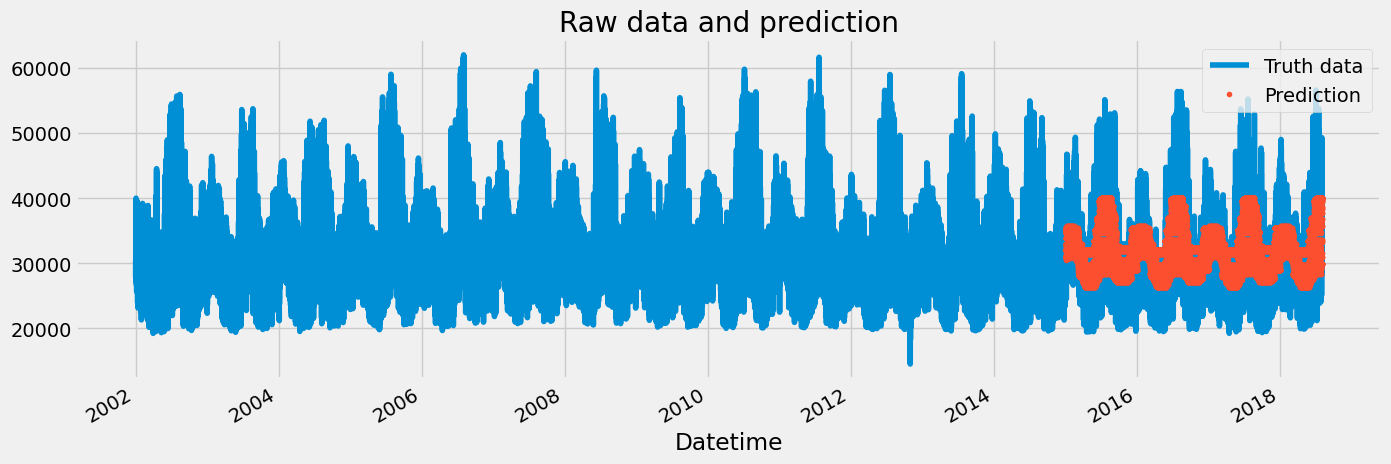

In [20]:
ax=df[['PJME_MW']].plot(figsize=(15,5))
df['prediction'].plot(ax=ax,style='.')
plt.legend(['Truth data','Prediction'])
ax.set_title('Raw data and prediction')
plt.show()

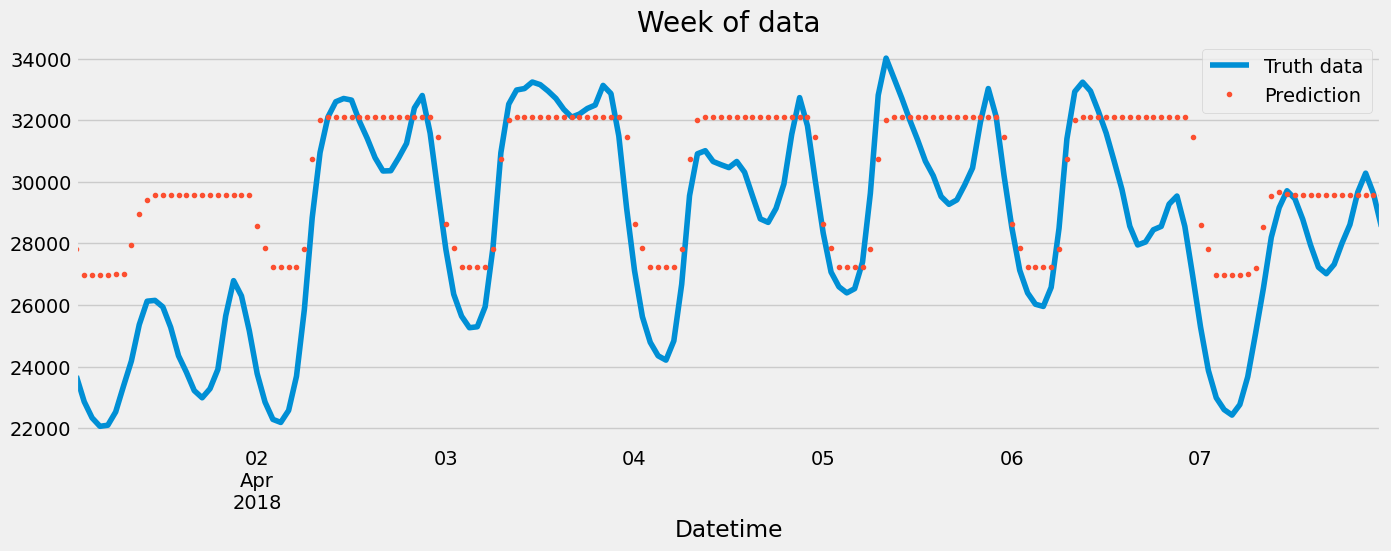

In [21]:
ax=df.loc[(df.index>'2018-04-01') & (df.index<'2018-04-08'),'PJME_MW'].plot(
    figsize=(15,5),
    title='Week of data'
)
df.loc[(df.index>'2018-04-01') & (df.index<'2018-04-08'),'prediction'].plot(
    style='.')
plt.legend(['Truth data','Prediction'])
plt.show()


In [22]:
score=np.sqrt(mean_squared_error(test['PJME_MW'],test['prediction']))
print(f"RMSE score on test set:{score:0.2f}")

RMSE score on test set:4325.35


In [23]:
test['error']=np.abs(test['PJME_MW']-test['prediction'])
test

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,prediction,error
Datetime,,,,,,,,,
2015-01-01 00:00:00,32802.0,0,3,1,1,2015,1,32089.679688,712.320312
2015-01-01 01:00:00,31647.0,1,3,1,1,2015,1,31160.828125,486.171875
2015-01-01 02:00:00,30755.0,2,3,1,1,2015,1,30993.898438,238.898438
2015-01-01 03:00:00,30189.0,3,3,1,1,2015,1,30993.898438,804.898438
2015-01-01 04:00:00,29890.0,4,3,1,1,2015,1,30993.898438,1103.898438
...,...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214,39690.410156,4366.589844
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214,39462.277344,3793.722656
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214,38719.152344,2832.847656


In [24]:
test['date']=test.index.date

In [25]:
test.groupby('date')['error'].mean().sort_values(ascending=False).head(5)

date
2016-08-13    12092.418620
2016-08-14    11407.225098
2018-01-06    11024.924316
2015-02-20    10791.006348
2016-09-09    10337.963704
Name: error, dtype: float64

In [26]:
test.groupby('date')['error'].mean().sort_values(ascending=True).head(5)

date
2016-12-29    764.857666
2016-12-30    783.728760
2017-11-18    849.959310
2017-03-18    870.751546
2018-04-03    880.189860
Name: error, dtype: float64